In [2]:
!pip install efficientnet

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
from tensorflow.keras.optimizers import Adam, Adamax
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
import timeit
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix)
import cv2




2025-06-03 20:37:32.611852: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748983052.837926      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748983052.909041      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [7]:
train_data_dir = "/kaggle/input/knee-osteoarthritis-dataset-with-severity/train"
validation_data_dir = "/kaggle/input/knee-osteoarthritis-dataset-with-severity/val"
test_data_dir = "/kaggle/input/knee-osteoarthritis-dataset-with-severity/test"

In [10]:
np.random.seed(12049)

In [12]:
def get_classes(data_path, classes, data):
   
    print(f"----{data}----")
    knee_severity = {}
    total_count = 0

    for i in range(len(classes)):
        imgs = os.listdir(os.path.join(data_path, str(i)))
        knee_severity[i] = imgs
        total_count += len(imgs)

    for k, v in knee_severity.items():
        print(
            f"Grade {k}-{classes[k]}: {len(v)} images, {round((len(v)*100)/total_count, 2)}%"
        )

    return knee_severity


In [14]:
def plot_classes(dict_classes, data_path, classes, data):


  # Loop through each class
  for k, v in dict_classes.items():
    print(f"{data}-{classes[k]}")

    # Create a figure for visualization
    plt.figure(figsize=(10, 5))  # Adjust figure height for better display

    # Display 5 sample images per class
    for i in range(5):
      if i >= len(v):  # Handle cases with less than 5 images
        break

      # Construct image path
      img_path = os.path.join(data_path, str(k), v[i])

      # Load the image
      img = tf.keras.preprocessing.image.load_img(img_path)

      # Create a subplot and remove axes for cleaner presentation
      plt.subplot(1, 5, 1 + i, xticks=[], yticks=[])
      plt.imshow(img)
      plt.title(f"Grade {k}")

    # Display the plot
    plt.show()

In [15]:
class_names=['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']

In [16]:
train_data=get_classes(train_data_dir, class_names, 'Train')
valid_data=get_classes(validation_data_dir, class_names, 'Valid')
test_data=get_classes(test_data_dir, class_names, 'Test')

----Train----
Grade 0-Healthy: 2286 images, 39.56%
Grade 1-Doubtful: 1046 images, 18.1%
Grade 2-Minimal: 1516 images, 26.24%
Grade 3-Moderate: 757 images, 13.1%
Grade 4-Severe: 173 images, 2.99%
----Valid----
Grade 0-Healthy: 328 images, 39.71%
Grade 1-Doubtful: 153 images, 18.52%
Grade 2-Minimal: 212 images, 25.67%
Grade 3-Moderate: 106 images, 12.83%
Grade 4-Severe: 27 images, 3.27%
----Test----
Grade 0-Healthy: 639 images, 38.59%
Grade 1-Doubtful: 296 images, 17.87%
Grade 2-Minimal: 447 images, 26.99%
Grade 3-Moderate: 223 images, 13.47%
Grade 4-Severe: 51 images, 3.08%


Train data-Healthy


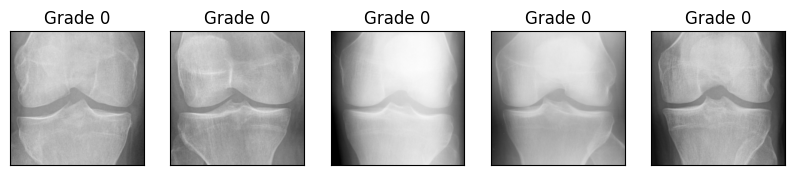

Train data-Doubtful


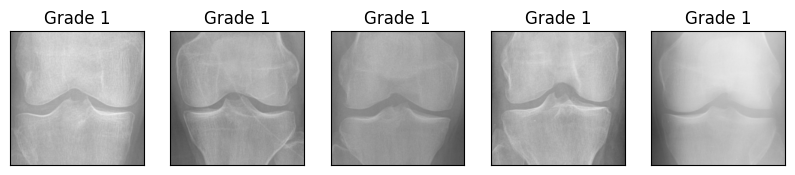

Train data-Minimal


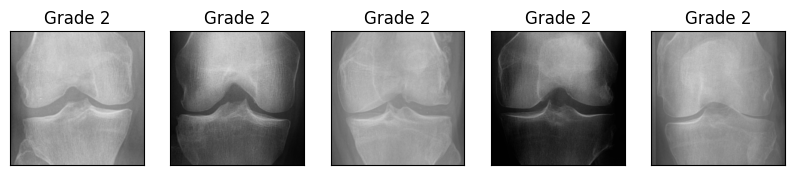

Train data-Moderate


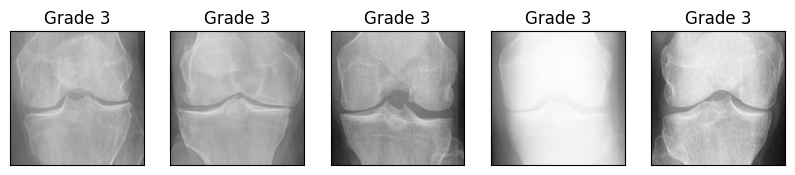

Train data-Severe


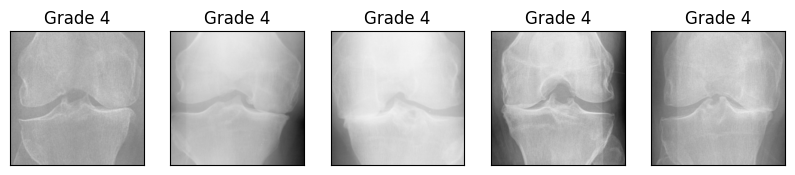

In [ ]:
plot_classes(train_data, train_data_dir, class_names, 'Train data')

In [19]:
model_name="EfficientNet-B3"

target_size=(224, 224)
epochs=30
batch_size=256
img_shape=(224, 224, 3)

save_model_ft=os.path.join('models', f'model_{model_name}_ft.hdf5')

In [21]:
def custom_preprocessing(img):
    # Convert the image to grayscale (if it's not already)
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img.dtype != np.uint8:
        img = np.uint8(img)

    # Apply histogram equalization
    equalized_img = cv2.equalizeHist(img)

    # Convert the equalized image back to 3 channels (RGB)
    equalized_img = cv2.cvtColor(equalized_img, cv2.COLOR_GRAY2BGR)

    return equalized_img

Found 5778 images belonging to 5 classes.


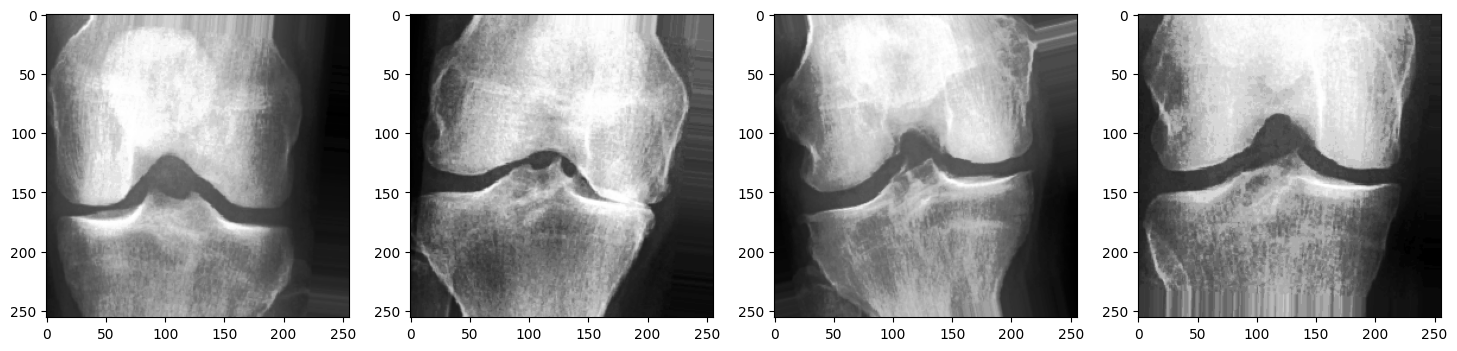

In [22]:
datagen=tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=custom_preprocessing,
    brightness_range=[0.4, 0.6],
    zoom_range=0.05,
    fill_mode="nearest",
    rotation_range=20, 
    width_shift_range=0.1, 
    height_shift_range=0.1,  
    horizontal_flip=True,
    shear_range=0.1
)
imagegen=datagen.flow_from_directory(train_data_dir, batch_size=1)
fig, rows=plt.subplots(nrows=1, ncols=4, figsize=(18, 18))
for row in rows:
   row.imshow(next(imagegen)[0][0].astype("uint8")) 
plt.show()

In [25]:
aug_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=custom_preprocessing,
    brightness_range=[0.4, 0.6],
    zoom_range=0.05,
    fill_mode="nearest",
    rotation_range=20, 
    width_shift_range=0.1, 
    height_shift_range=0.1,  
    horizontal_flip=True,
    shear_range=0.1
)

noaug_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=custom_preprocessing,
)

In [11]:
#def apply_clahe(image):
    # Convert the image to grayscale (8-bit unsigned, single-channel)
    #gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Ensure the image is in CV_8UC1 format
    #if gray_image.dtype != np.uint8:
       # gray_image = np.uint8(gray_image)

    # Apply CLAHE to the grayscale image
   # clahe = cv2.createCLAHE(clipLimit=40.0, tileGridSize=(8, 8))
   # enhanced_image = clahe.apply(gray_image)

    # Convert the enhanced grayscale image back to RGB color space
   # enhanced_rgb = cv2.cvtColor(enhanced_image, cv2.COLOR_GRAY2RGB)

   # return enhanced_rgb

In [ ]:
#datagen=tf.keras.preprocessing.image.ImageDataGenerator(
   # preprocessing_function=lambda x: apply_clahe(x),
   # brightness_range=[0.4, 0.6],
   # zoom_range=0.05,
    #fill_mode="nearest",
   # rotation_range=20, 
    #width_shift_range=0.1, 
   # height_shift_range=0.1,  
   # horizontal_flip=True,
   # shear_range=0.1
#)
#imagegen=datagen.flow_from_directory(train_data_dir, batch_size=1)
#fig, rows=plt.subplots(nrows=1, ncols=4, figsize=(18, 18))
#for row in rows:
#  row.imshow(next(imagegen)[0][0].astype("uint8")) 
#plt.show()

In [13]:
#aug_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
   # preprocessing_function=lambda x: apply_clahe(x),
  #  brightness_range=[0.4, 0.6],
   # zoom_range=0.05,
   # fill_mode="nearest",
   # rotation_range=20, 
   # width_shift_range=0.1, 
   # height_shift_range=0.1,  
   # horizontal_flip=True,
   # shear_range=0.1
#)

#noaug_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    #preprocessing_function=lambda x: apply_clahe(x),
#)
     

In [26]:
train_generator = aug_datagen.flow_from_directory(
    train_data_dir, class_mode="categorical", target_size=target_size, shuffle=True
)

valid_generator = noaug_datagen.flow_from_directory(
    validation_data_dir,
    class_mode="categorical",
    target_size=target_size,
    shuffle=False,
)

Found 5778 images belonging to 5 classes.
Found 826 images belonging to 5 classes.


In [28]:
y_train = train_generator.labels
y_val = valid_generator.labels

In [29]:
unique, counts = np.unique(y_train, return_counts=True)
print("Train: ", dict(zip(unique, counts)))

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
train_class_weights = dict(enumerate(class_weights))
print(train_class_weights)

Train:  {0: 2286, 1: 1046, 2: 1516, 3: 757, 4: 173}
{0: 0.5055118110236221, 1: 1.1047801147227534, 2: 0.7622691292875989, 3: 1.5265521796565389, 4: 6.679768786127168}


In [32]:
from efficientnet.tfkeras import EfficientNetB3

input_shape = (224, 224, 3)

model = EfficientNetB3(input_shape=input_shape, weights='imagenet', include_top=False)

In [33]:
#[-100:]
for layer in model.layers [-150:] :
    layer.trainable = True

model_ft = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer(shape=(224, 224, 3)),
        model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(5, activation="softmax", kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    ]
)

model_ft.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnet-b3 (Functional)         │ (None, 7, 7, 1536)          │      10,783,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1536)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1536)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         196,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,980,909 (41.89 MB)

 Trainable params: 10,893,613 (41.56 MB)

 Non-trainable params: 87,296 (341.00 KB)

In [34]:
#model_ft.compile(
 #   optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
#)
from keras.callbacks import ReduceLROnPlateau

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

#scheduler = ReduceLROnPlateau(
    #monitor='val_loss',  # Monitor validation loss
    #factor=0.7,           # Reduce learning rate by 70%
    #patience=5,          # Wait for 5 epochs before reducing
    #min_lr=1e-6,         # Minimum learning rate
#)
 
model_ft.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])



In [ ]:
start_ft = timeit.default_timer()

history = model_ft.fit(
    train_generator,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=valid_generator,
    class_weight=train_class_weights,
    verbose=1,
   # callbacks=[scheduler]
)

stop_ft = timeit.default_timer()

In [36]:
execution_time_ft = (stop_ft - start_ft) / 60
print(
    f"Model {model_name} fine tuning executed in {execution_time_ft:.2f} minutes"
)

Model EfficientNet-B3 fine tuning executed in 45.39 minutes


In [38]:
model_ft.save(save_model_ft)

In [40]:
def get_plot_loss_acc(model, model_name):
    fig=plt.figure()
    plt.subplot(2, 1, 1)
    plt.plot(model.history.history["loss"])
    plt.plot(model.history.history["val_loss"])
    plt.title(f"{model_name} \n\n model loss")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.legend(["train", "valid"], loc="upper right")

    plt.subplot(2, 1, 2)
    plt.plot(model.history.history["accuracy"])
    plt.plot(model.history.history["val_accuracy"])
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(["train", "valid"], loc="lower right")

    plt.tight_layout()

In [ ]:
get_plot_loss_acc(model_ft, f"{model_name} Fine Tuning")

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Get training and validation loss and accuracy values
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_acc = history.history['accuracy']  # Assuming 'accuracy' is used as metric
    val_acc = history.history['val_accuracy']

    # Create subplots for loss and accuracy
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot loss curves
    axes[0].plot(train_loss, label='Training Loss')
    axes[0].plot(val_loss, label='Validation Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Plot accuracy curves
    axes[1].plot(train_acc, label='Training Accuracy')
    axes[1].plot(val_acc, label='Validation Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.show()

# Assuming you have trained your model using:
# history = model.fit(train_gen, epochs=num_epochs, validation_data=valid_gen)

# Call the function to plot the training history
plot_training_history(history)

# Evaluate on test data
test_loss, test_acc = model_ft.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

In [44]:
def get_evaluate(data, name, model):
    score_model=model.evaluate(data, verbose=1)
    print(f"{name} loss: {score_model[0]: .2f}")
    print(f"{name} accuracy: {score_model[1]: .2f}")

In [ ]:
get_evaluate(valid_generator, "Valid", model_ft)

In [46]:
def compute_confusion_matrix(ytrue, ypred, class_names, model_name):
    cm=confusion_matrix(
        y_true=ytrue.labels,
        y_pred=np.argmax(ypred, axis=1),
    )
    cmn=cm.astype("float")/cm.sum(axis=1)[:, np.newaxis]
    plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cmn,
        annot=True,
        fmt=".2f",
        cmap="Purples",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show(block=False)

def get_evaluate(data, name, model):
    score_model=model.evaluate(data, verbose=1)
    print(f"{name} loss: {score_model[0]: .2f}")
    print(f"{name} accuracy: {score_model[1]: .2f}")

def get_predict(data, model):
    predict_model=model.predict(data)
    return predict_model

def get_metrics(y_test, y_pred, model_name):
    acc=accuracy_score(y_test, y_pred)
    bal_acc=balanced_accuracy_score(y_test, y_pred)

    print(f"Accuracy Score - {model_name}: {acc: .2f}")
    print(f"Balanced Accuracy Score - {model_name}: {bal_acc: .2f}")
    print("\n")

    print(classification_report(y_test, y_pred))

In [ ]:
predict_model_ft = get_predict(valid_generator, model_ft)

get_metrics(
    valid_generator.labels,
    y_pred=np.argmax(predict_model_ft, axis=1),
    model_name=model_name,
)

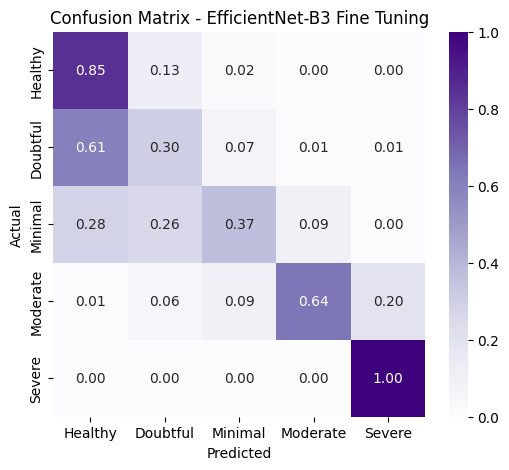

In [48]:
compute_confusion_matrix(
    valid_generator, predict_model_ft, class_names, f"{model_name} Fine Tuning"
)

In [49]:
test_generator = noaug_datagen.flow_from_directory(
    test_data_dir,
    batch_size=batch_size,
    class_mode="categorical",
    target_size=target_size,
    shuffle=False,
)

Found 1656 images belonging to 5 classes.


In [51]:
y_test = test_generator.labels

In [52]:
EfficientNet = tf.keras.models.load_model('models/model_EfficientNet-B5_ft.hdf5')

In [54]:
predictions_EfficientNet = EfficientNet.predict(test_generator)
score_EfficientNet=EfficientNet.evaluate(test_generator, verbose=1)
print('Test loss:', score_EfficientNet[0])
print('Test acc:', score_EfficientNet[1])

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 696ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 717ms/step - accuracy: 0.5954 - loss: 0.9889
Test loss: 0.8949826955795288
Test acc: 0.6376811861991882


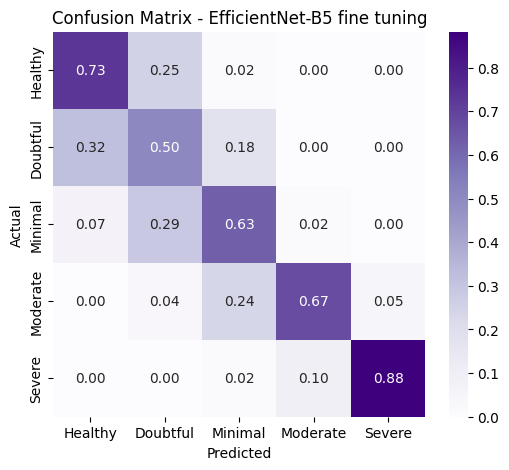

In [35]:
compute_confusion_matrix(
    test_generator,
    predictions_EfficientNet,
    class_names,
    f"{model_name} fine tuning",
)

In [36]:
EfficientNet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnet-b5 (Functional)    │ (None, 7, 7, 2048)     │    28,513,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,776,439 (109.77 MB)

 Trainable params: 28,603,701 (109.11 MB)

 Non-trainable params: 172,736 (674.75 KB)

 Optimizer params: 2 (12.00 B)

In [37]:
def make_gradcam_heatmap(grad_model, img_array, pred_index=None):
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [38]:
def save_and_display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)

    jet = cm.get_cmap("jet")

    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(
        superimposed_img
    )

    return superimposed_img

In [39]:
tests_data = get_classes(test_data_dir, class_names, 'test')

----test----
Grade 0-Healthy: 639 images, 38.59%
Grade 1-Doubtful: 296 images, 17.87%
Grade 2-Minimal: 447 images, 26.99%
Grade 3-Moderate: 223 images, 13.47%
Grade 4-Severe: 51 images, 3.08%


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.cm as cm

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def save_and_display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)

    jet = cm.get_cmap("jet")

    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    return superimposed_img

# Get an image from the test data
img_path = test_generator.filepaths[0] 
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
img = tf.keras.preprocessing.image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = tf.keras.applications.efficientnet.preprocess_input(img)

# Get the last convolutional layer name
last_conv_layer_name = "top_activation" 

# Create a GradCAM model
grad_model = tf.keras.models.Model([EfficientNet.inputs], [EfficientNet.get_layer(last_conv_layer_name).output, EfficientNet.output])

# Generate heatmap
heatmap = make_gradcam_heatmap(img, grad_model, last_conv_layer_name)

# Display GradCAM
superimposed_img = save_and_display_gradcam(img[0], heatmap)

plt.imshow(superimposed_img)
plt.show()

In [ ]:

conv_output = EfficientNet.get_layer("global_average_pooling2d").input

grad_model = tf.keras.models.Model(
    [EfficientNet.inputs], [conv_output, EfficientNet.output]
)

# model
EfficientNet.layers[-1].activation = None

In [ ]:
for k, v in tests_data.items():
    print(f"Test data - {class_names[k]}")
    plt.figure(figsize=(10, 28))
    for i in range(6):
        img_path = os.path.join(test_data_dir, str(k), v[i])
        # prepare image
        img = tf.keras.preprocessing.image.load_img(
            img_path, target_size=target_size
        )
        img = tf.keras.preprocessing.image.img_to_array(img)

        img_aux = img.copy()
        img_array = np.expand_dims(img_aux, axis=0)
        img_array = np.float32(img_array)
        img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

        y_pred = EfficientNet.predict(img_array, verbose=0)[0]

        heatmap = make_gradcam_heatmap(grad_model, img_array)
        image = save_and_display_gradcam(img, heatmap)

        plt.subplot(1, 6, 1 + i, xticks=[], yticks=[])
        plt.imshow(image)
        plt.title(
            f"True {class_names[k]}\nPred: {class_names[np.argmax(y_pred)]}"
        )
        plt.xlabel(
            "\n".join([f"{c} = {p:.2f}" for c, p in zip(class_names, y_pred)])
        )
    plt.show()